In [1]:
# Core scverse libraries
import os
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt


# === INPUT PATHS ===
msi_input_folder = "/home/ajarrah/PhD_Thesis/chapter_2/h5ad_data_processed_4lockmasses_filtered/"
msi_icommon_mzs_csv_input_path = "/home/ajarrah/PhD_Thesis/chapter_2/csv_data/common_mz_clusters_improved.csv"

rna_input_file = '/home/ajarrah/PhD_Thesis/chapter_3/aggregated_h5ad_data/aggregated_mouse_brain_202502.h5ad'
rna_input_folder = "/home/ajarrah/PhD_Thesis/chapter_3/h5ad_data/"

In [2]:
# Your list of sample IDs (also used as keys in the dictionary)
msi_aad_1 = sc.read_h5ad(os.path.join(msi_input_folder, "aad_1_filtered.h5ad"))
msi_aad_2 = sc.read_h5ad(os.path.join(msi_input_folder, "aad_2_filtered.h5ad"))
msi_aad_3 = sc.read_h5ad(os.path.join(msi_input_folder, "aad_3_filtered.h5ad"))
msi_aad_4 = sc.read_h5ad(os.path.join(msi_input_folder, "aad_4_filtered.h5ad"))
msi_ac_1 = sc.read_h5ad(os.path.join(msi_input_folder, "ac_1_filtered.h5ad"))
msi_ac_2 = sc.read_h5ad(os.path.join(msi_input_folder, "ac_2_filtered.h5ad"))
msi_ac_3 = sc.read_h5ad(os.path.join(msi_input_folder, "ac_3_filtered.h5ad"))
msi_ac_4 = sc.read_h5ad(os.path.join(msi_input_folder, "ac_4_filtered.h5ad"))
msi_yad_1 = sc.read_h5ad(os.path.join(msi_input_folder, "yad_1_filtered.h5ad"))
msi_yad_2 = sc.read_h5ad(os.path.join(msi_input_folder, "yad_2_filtered.h5ad"))
msi_yad_3 = sc.read_h5ad(os.path.join(msi_input_folder, "yad_3_filtered.h5ad"))
msi_yad_4 = sc.read_h5ad(os.path.join(msi_input_folder, "yad_4_filtered.h5ad"))
msi_yc_1 = sc.read_h5ad(os.path.join(msi_input_folder, "yc_1_filtered.h5ad"))
msi_yc_2 = sc.read_h5ad(os.path.join(msi_input_folder, "yc_2_filtered.h5ad"))
msi_yc_3 = sc.read_h5ad(os.path.join(msi_input_folder, "yc_3_filtered.h5ad"))
msi_yc_4 = sc.read_h5ad(os.path.join(msi_input_folder, "yc_4_filtered.h5ad"))

msi_sample_list = [
    msi_aad_1, msi_aad_2, msi_aad_3, msi_aad_4,
    msi_ac_1, msi_ac_2, msi_ac_3, msi_ac_4,
    msi_yad_1, msi_yad_2, msi_yad_3, msi_yad_4,
    msi_yc_1, msi_yc_2, msi_yc_3, msi_yc_4
]

msi_sample_ids = [
    "aad_1", "aad_2", "aad_3", "aad_4",
    "ac_1", "ac_2", "ac_3", "ac_4",
    "yad_1", "yad_2", "yad_3", "yad_4",
    "yc_1", "yc_2", "yc_3", "yc_4"
]

# Map sample ID → AnnData object
msi_sample_map = dict(zip(msi_sample_ids, msi_sample_list))

# Assuming sample_list contains your AnnData objects and their variable names are like 'aad_1', 'ac_1', etc.
# They must be defined variables or in a dictionary for easy iteration.

# Example: if you have them in a dictionary like sample_map = {'aad_1': aad_1, ...}

for sample_id in msi_sample_list:
    msi_adata = sample_id  # Get the AnnData object by variable name string
    # Sum all intensities for each spot (row) across all m/z (columns)
    tic = msi_adata.X.sum(axis=1)  # shape (n_spots, 1) or (n_spots,) depending on sparse or dense
    
    # If sparse, convert to flat array
    if hasattr(tic, "A1"):  # sparse matrix
        tic = tic.A1
    else:
        tic = np.asarray(tic).flatten()

    # Add TIC as a new column in obs
    msi_adata.obs["Processed_TIC"] = tic
    

# === STEP 3: Load common m/z list ===
common_mz_df = pd.read_csv(msi_icommon_mzs_csv_input_path)


# Example: convert group/sample to sample_id that matches your sample_map keys
def make_sample_id(row):
    # lower group, then underscore, then sample number
    return f"{row['group'].lower()}_{row['sample']}"

common_mz_df['sample_id'] = common_mz_df.apply(make_sample_id, axis=1)

pivot_df = common_mz_df.pivot(index='sample_id', columns='common_group_name', values='mzs')

msi_order = [
    'yc_1', 'yc_2', 'yc_3', 'yc_4',
    'yad_1', 'yad_2', 'yad_3', 'yad_4',
    'ac_1', 'ac_2', 'ac_3', 'ac_4',
    'aad_1', 'aad_2', 'aad_3', 'aad_4'
]

# Assuming pivot_df is your pivoted DataFrame with index = sample_id
pivot_df_sorted = pivot_df.loc[pivot_df.index.intersection(msi_order)]
pivot_df_sorted = pivot_df_sorted.loc[msi_order]

pivot_df_sorted
pivot_df_sorted.columns

Index([ 326.1934,  337.1867,  339.2243,  340.2283,  341.2403,  351.1655,
        351.2252,  352.2294,  353.2401,  354.2482,
       ...
        995.6423,  996.6482,  998.6634,  999.6775, 1000.6777, 1001.6889,
       1002.6913, 1003.7043, 1017.6613, 1088.8161],
      dtype='float64', name='common_group_name', length=528)

In [3]:
rna_adata = sc.read_h5ad(rna_input_file)

rna_aad_1 = sc.read_h5ad(os.path.join(rna_input_folder, "A1_Aged_AD_Mouse_Brain_202502.h5ad"))
rna_aad_2 = sc.read_h5ad(os.path.join(rna_input_folder, "B1_Aged_AD_Mouse_Brain_202502.h5ad"))
rna_aad_3 = sc.read_h5ad(os.path.join(rna_input_folder, "C1_Aged_AD_Mouse_Brain_202502.h5ad"))
rna_aad_4 = sc.read_h5ad(os.path.join(rna_input_folder, "D1_Aged_AD_Mouse_Brain_202502.h5ad"))
rna_ac_1 = sc.read_h5ad(os.path.join(rna_input_folder, "A1_Aged_Control_Mouse_Brain_202502.h5ad"))
rna_ac_2 = sc.read_h5ad(os.path.join(rna_input_folder, "B1_Aged_Control_Mouse_Brain_202502.h5ad"))
rna_ac_3 = sc.read_h5ad(os.path.join(rna_input_folder, "C1_Aged_Control_Mouse_Brain_202502.h5ad"))
rna_ac_4 = sc.read_h5ad(os.path.join(rna_input_folder, "D1_Aged_Control_Mouse_Brain_202502.h5ad"))
rna_yad_1 = sc.read_h5ad(os.path.join(rna_input_folder, "A1_Young_AD_Mouse_Brain_202502.h5ad"))
rna_yad_2 = sc.read_h5ad(os.path.join(rna_input_folder, "B1_Young_AD_Mouse_Brain_202502.h5ad"))
rna_yad_3 = sc.read_h5ad(os.path.join(rna_input_folder, "C1_Young_AD_Mouse_Brain_202502.h5ad"))
rna_yad_4 = sc.read_h5ad(os.path.join(rna_input_folder, "D1_Young_AD_Mouse_Brain_202502.h5ad"))
rna_yc_1 = sc.read_h5ad(os.path.join(rna_input_folder, "A1_Young_Control_Mouse_Brain_202502.h5ad"))
rna_yc_2 = sc.read_h5ad(os.path.join(rna_input_folder, "B1_Young_Control_Mouse_Brain_202502.h5ad"))
rna_yc_3 = sc.read_h5ad(os.path.join(rna_input_folder, "C1_Young_Control_Mouse_Brain_202502.h5ad"))
rna_yc_4 = sc.read_h5ad(os.path.join(rna_input_folder, "D1_Young_Control_Mouse_Brain_202502.h5ad"))

rna_data_name = [rna_yc_1, rna_yc_2, rna_yc_3, rna_yc_4,
                rna_yad_1, rna_yad_2, rna_yad_3, rna_yad_4,
                rna_ac_1, rna_ac_2, rna_ac_3, rna_ac_4,
                rna_aad_1, rna_aad_2, rna_aad_3, rna_aad_4]

rna_sample_name = ["YC_1", "YC_2", "YC_3", "YC_4",
                "YAD_1", "YAD_2", "YAD_3", "YAD_4",
                "AC_1", "AC_2", "AC_3", "AC_4",
                "AAD_1", "AAD_2", "AAD_3", "AAD_4"]

rna_sample_display_name = ["Young Control 1", "Young Control 2", "Young Control 3", "Young Control 4",
                       "Young AD 1", "Young AD 2", "Young AD 3", "Young AD 4",
                       "Aged Control 1", "Aged Control 2", "Aged Control 3", "Aged Control 4",
                       "Aged AD 1", "Aged AD 2", "Aged AD 3", "Aged AD 4"]

# Ensure matrix is dense or use .A1 for sparse matrices
if isinstance(rna_adata.X, np.ndarray):
    non_zero_genes = rna_adata.X.sum(axis=0) != 0
else:
    non_zero_genes = np.array((rna_adata.X.sum(axis=0) != 0)).ravel()  # for sparse matrix

rna_adata = rna_adata[:, non_zero_genes].copy()


# Normalize total counts per cell (CPM / library size normalization)
sc.pp.normalize_total(rna_adata, target_sum=1e2)   # or 1e6 depending on preference
for data in rna_data_name:
    sc.pp.normalize_total(data, target_sum=1e2)   # or 1e6 depending on preference

# Read the CSV
# Read only selected columns
tissue_positions = pd.read_csv(
    "/home/ajarrah/PhD_Thesis/chapter_4/tissue_positions/tissue_positions.csv",
    usecols=["barcode", "array_row", "array_col"])

# Show first rows
print(tissue_positions.head())


spot_spacing = 100  # µm center-to-center
n_rows = tissue_positions['array_row'].max() + 1
n_cols = tissue_positions['array_col'].max() + 1

coords_um = []
for _, row in tissue_positions.iterrows():
    r, c = row['array_row'], row['array_col']
    y = r * (np.sqrt(3)/2 * spot_spacing)
    x = c * spot_spacing/2 
    coords_um.append((x, y))

coords_um = np.array(coords_um)
tissue_positions['x_um'] = coords_um[:, 0]
tissue_positions['y_um'] = coords_um[:, 1]

/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


              barcode  array_row  array_col
0  ACGCCTGACACGCGCT-1          0          0
1  TACCGATCCAACACTT-1          1          1
2  ATTAAAGCGGACGAGC-1          0          2
3  GATAAGGGACGATTAG-1          1          3
4  GTGCAAATCACCAATA-1          0          4


In [4]:
from matplotlib.colors import LinearSegmentedColormap

# === COLOR SCALE ===
custom_cmap = LinearSegmentedColormap.from_list("custom_scale", [
    (0.0, "#454545"),      # dark gray
    (0.00000001, "#000000"),  # black
    (0.10, "#000080"),     # navy
    (0.15, "#0000FF"),     # blue
    (0.30, "#8000FF"),     # purple-ish
    (0.45, "#FF0000"),     # red
    (0.60, "#FF8000"),     # orange
    (0.75, "#FFFF00"),     # yellow
    (1.0, "#FFFFFF")       # white
])


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.patches import Circle, Polygon
from scipy.spatial import cKDTree


def plot_spot_interpolation(
    adata,
    tissue_positions,
    gene,
    spot_diameter=55,
    spot_spacing=100,
    cmap_name="viridis",
    figsize=(12, 12),
    alpha_rhombi=0.7,
    draw_poly_edges=False,
    draw_spot_edges=True,
):
    """
    Plot spatial transcriptomics spots with interpolated rhombus regions
    between neighboring spots.

    Parameters
    ----------
    adata : AnnData
        Expression data (must include `var_names` for genes).
    tissue_positions : pd.DataFrame
        DataFrame with columns ['barcode', 'x_um', 'y_um'].
    gene : str
        Gene to visualize.
    spot_diameter : float
        Diameter of spots (µm).
    spot_spacing : float
        Approximate center-to-center spacing between spots (µm).
    cmap_name : str
        Matplotlib colormap name.
    figsize : tuple
        Figure size (width, height).
    alpha_rhombi : float
        Transparency for rhombus patches.
    draw_edges : bool
        Whether to draw rhombus edges.
    """

    # --- Step 1: extract data ---
    spot_radius = spot_diameter / 2
    x = tissue_positions["x_um"].values
    y = tissue_positions["y_um"].values

    expr = adata[:, adata.var_names == gene].X.toarray().flatten()
    barcode_to_expr = dict(zip(adata.obs_names, expr))
    expr_full = tissue_positions["barcode"].map(barcode_to_expr).to_numpy()

    # --- Step 2: build KDTree ---
    coords = np.column_stack([x, y])
    tree = cKDTree(coords)

    # --- Step 3: compute rhombi ---
    mid_polys, mid_vals = [], []
    for i, (xi, yi, vi) in enumerate(zip(x, y, expr_full)):
        if np.isnan(vi):
            continue
        dists, idxs = tree.query([xi, yi], k=7)  # self + 6 neighbors
        for j in idxs[1:]:
            if np.isnan(expr_full[j]):
                continue
            xj, yj, vj = x[j], y[j], expr_full[j]

            # Midpoint and averaged value
            mx, my = (xi + xj) / 2, (yi + yj) / 2
            mv = (vi + vj) / 2

            dx, dy = xj - xi, yj - yi
            length = np.sqrt(dx**2 + dy**2)
            if length == 0:
                continue

            # perpendicular vector
            px, py = -dy / length, dx / length

            # short axis = correct hex proportion
            half_short = length / (2 * np.sqrt(3))

            # polygon corners
            p1 = (mx - dx / 2, my - dy / 2)  # xi side
            p2 = (mx + dx / 2, my + dy / 2)  # xj side
            p3 = (mx + px * half_short, my + py * half_short)
            p4 = (mx - px * half_short, my - py * half_short)

            mid_polys.append([p1, p3, p2, p4])
            mid_vals.append(mv)

    # --- Step 4: plot ---
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_aspect("equal")

    if isinstance(cmap_name, str):
        cmap = plt.get_cmap(cmap_name)
    else:
        cmap = cmap_name  # assume it’s already a colormap object
        
    norm = Normalize(vmin=np.nanmin(expr_full), vmax=np.nanmax(expr_full))

    # rhombi
    for poly, val in zip(mid_polys, mid_vals):
        patch = Polygon(
            poly,
            closed=True,
            facecolor=cmap(norm(val)),
            edgecolor="k" if draw_poly_edges else "none",
            lw=0.2,
            alpha=alpha_rhombi,
        )
        ax.add_patch(patch)

    # circles
    for xi, yi, val in zip(x, y, expr_full):
        if not np.isnan(val):
            circle = Circle(
                (xi, yi),
                radius=spot_radius,
                facecolor=cmap(norm(val)),
                edgecolor="k"if draw_spot_edges else "none",
                lw=0.2,
            )
            ax.add_patch(circle)

    ax.set_xlim(x.min() - 2 * spot_radius, x.max() + 2 * spot_radius)
    ax.set_ylim(y.min() - 2 * spot_radius, y.max() + 2 * spot_radius)
    ax.invert_yaxis()
    #ax.invert_xaxis()
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.set_title(f"{gene} expression (spots + interpolated rhombi)")

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label=f"{gene} expression")

    plt.show()


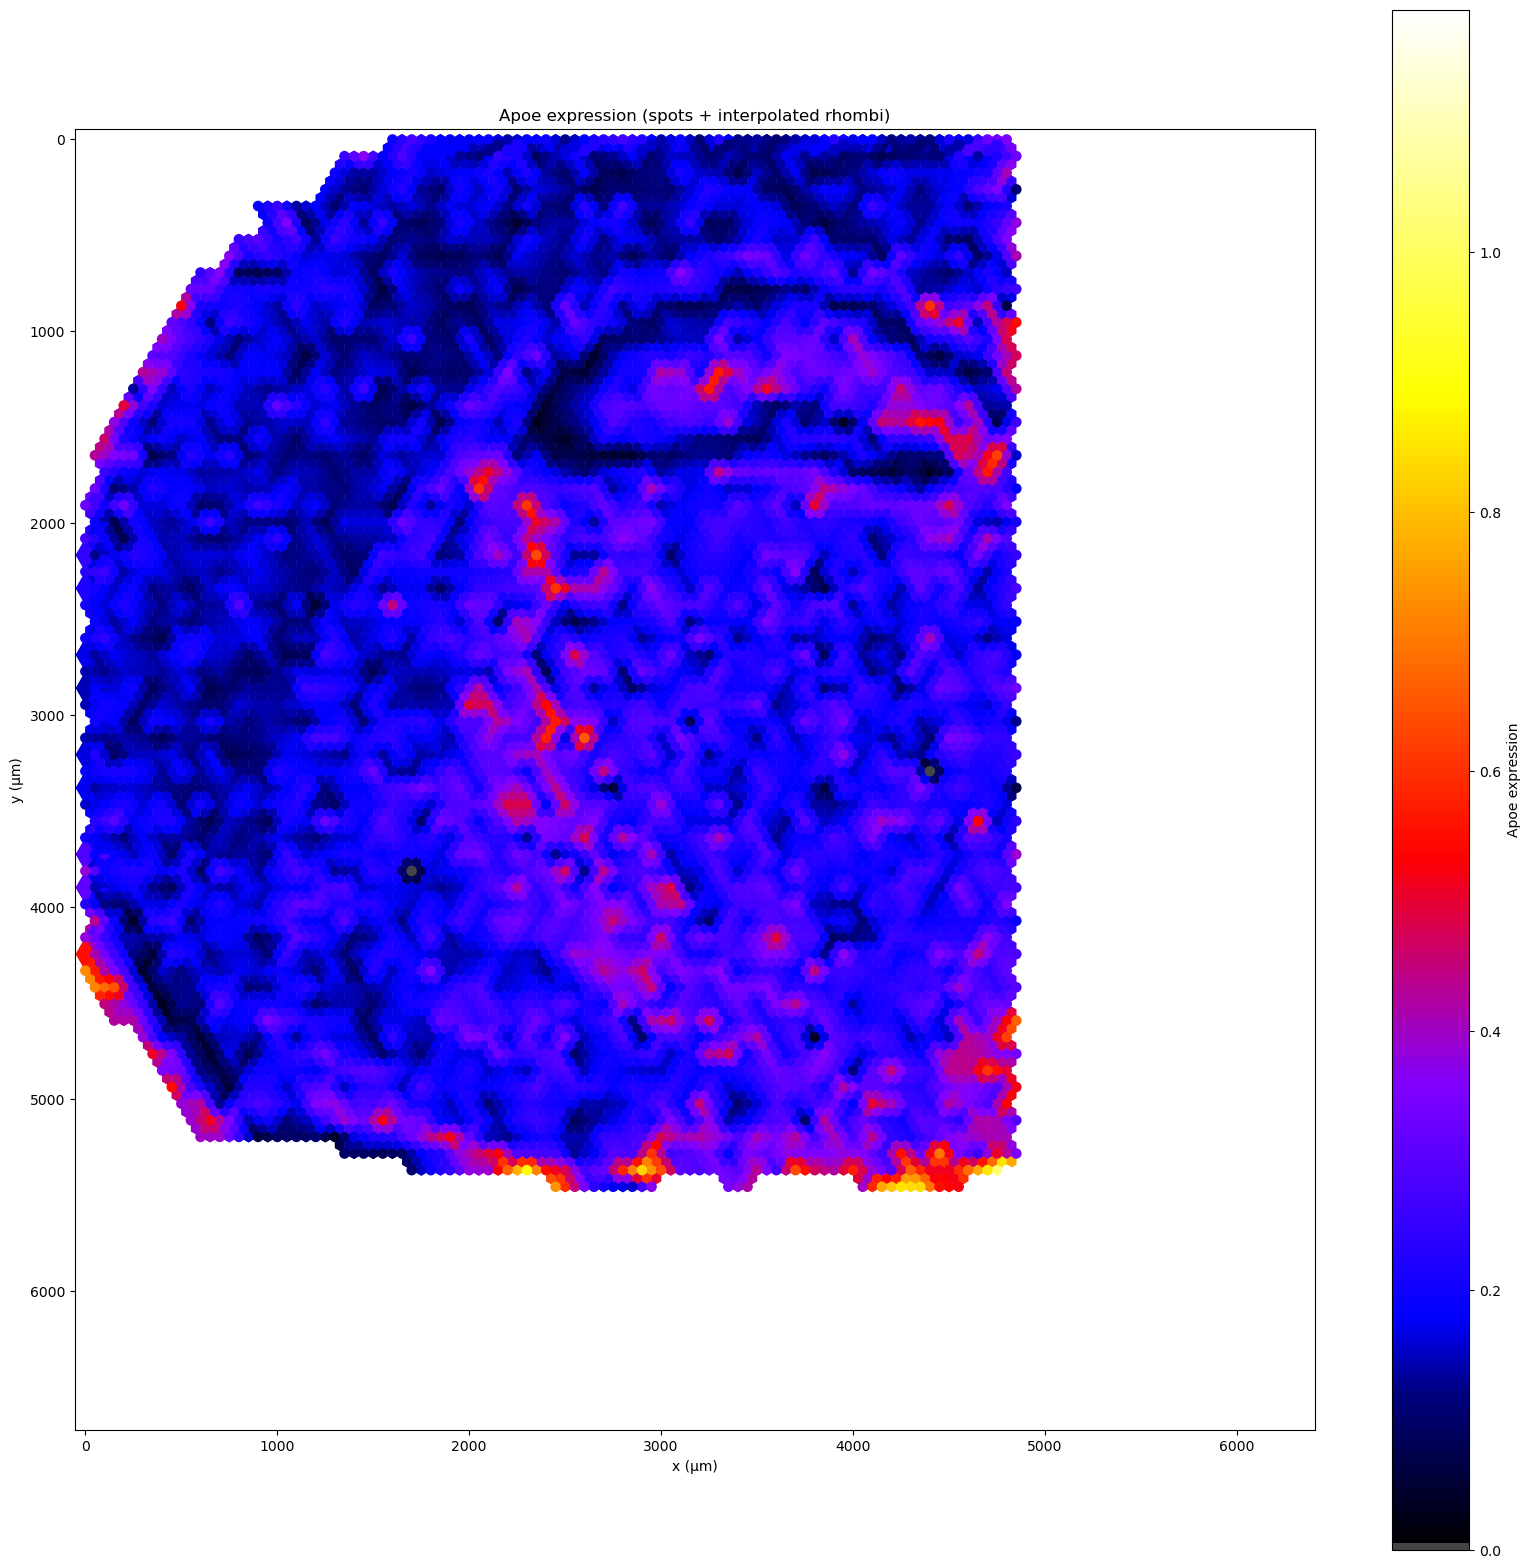

In [6]:
plot_spot_interpolation(
    rna_yad_1,
    tissue_positions,
    gene="Apoe",
    spot_diameter=55,
    spot_spacing=100,
    cmap_name=custom_cmap,
    figsize=(20, 20),
    alpha_rhombi=1,
    draw_poly_edges=False,
    draw_spot_edges=False
)

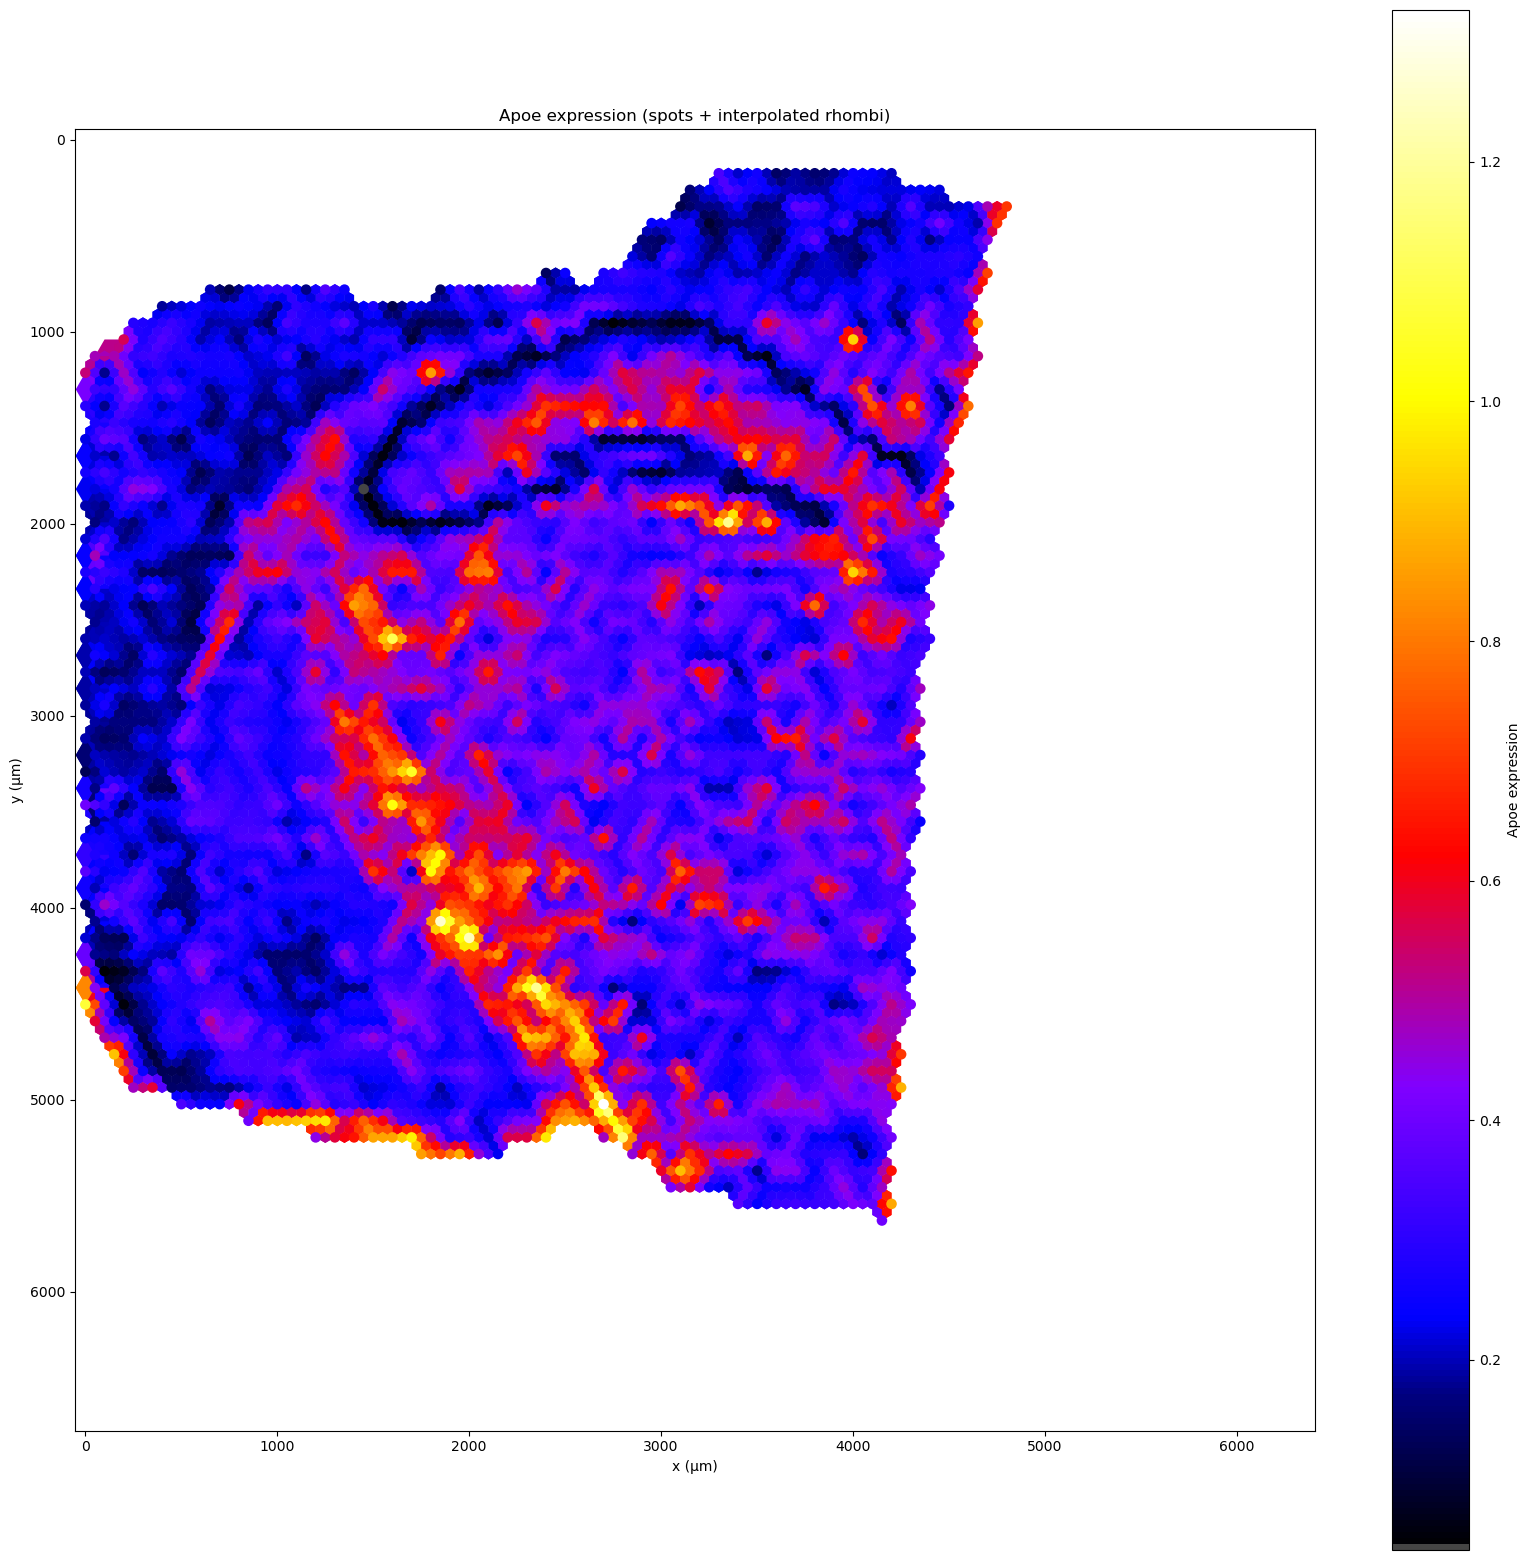

In [7]:
plot_spot_interpolation(
    rna_aad_4,
    tissue_positions,
    gene="Apoe",
    spot_diameter=55,
    spot_spacing=100,
    cmap_name=custom_cmap,
    figsize=(20, 20),
    alpha_rhombi=1,
    draw_poly_edges=False,
    draw_spot_edges=False
)

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_single_mz_animal(
    adata,
    mz_val,
    tol=0.001,
    vmax_percentile=99.9,
    square_size=60,   # µm per pixel (both x and y)
    cmap=None
):
    """
    Plot TIC-normalized intensity for one m/z and one sample, with each square
    representing 'square_size' µm × 'square_size' µm.
    """

    # --- Extract m/z index ---
    mz_axis = adata.var_names.astype(float).values
    mz_diff = np.abs(mz_axis - mz_val)
    if np.min(mz_diff) > tol:
        print(f"m/z {mz_val} not found within tolerance {tol}")
        return
    mz_index = np.argmin(mz_diff)

    # --- Extract intensities ---
    intensities = adata.X[:, mz_index].toarray().flatten() if hasattr(adata.X, "toarray") else adata.X[:, mz_index]

    # --- Extract coordinates & TIC ---
    x = adata.obs["x"].values
    y = adata.obs["y"].values
    tic = adata.obs["Processed_TIC"].values

    # Normalize by TIC
    normalized_intensities = intensities / tic*100
    normalized_intensities = np.nan_to_num(normalized_intensities, nan=0.0, posinf=0.0, neginf=0.0)

    # --- Build a grid ---
    x_unique = np.unique(x)
    y_unique = np.unique(y)
    x_size = len(x_unique)
    y_size = len(y_unique)

    # Map intensities to grid
    grid = np.full((y_size, x_size), np.nan)
    for xi, yi, val in zip(x, y, normalized_intensities):
        x_idx = np.where(x_unique == xi)[0][0]
        y_idx = np.where(y_unique == yi)[0][0]
        grid[y_idx, x_idx] = val

    # --- Color scaling ---
    vmax_value = np.percentile(normalized_intensities, vmax_percentile)

    # --- Plot ---
    extent = [x.min(), x.max() + square_size, y.min(), y.max() + square_size]  # in µm
    plt.figure(figsize=(x_size * square_size / 1000, y_size * square_size / 1000))  
    # scale figure size in mm (1000 µm = 1 mm)

    plt.imshow(grid, cmap=cmap if cmap else "viridis",
               origin="lower", extent=extent,
               vmin=0, vmax=vmax_value, interpolation="none")
    
    plt.colorbar()

    plt.axis("equal")
    plt.axis("off")
    plt.show()

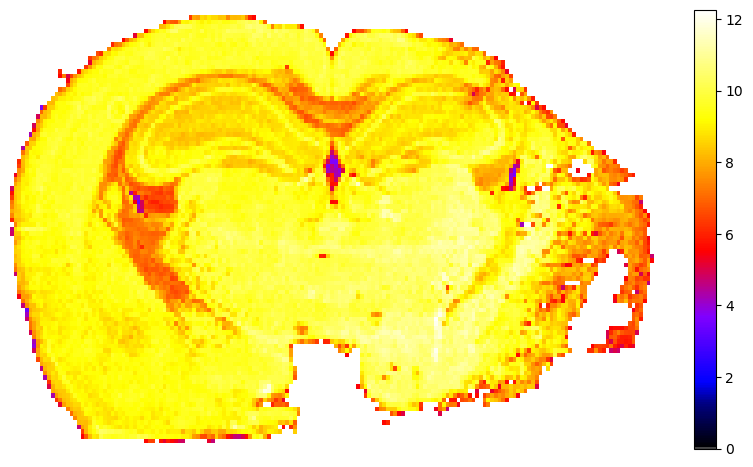

In [9]:
plot_single_mz_animal(
    adata=msi_sample_list[2],
    mz_val=760.585,
    tol=0.01,
    vmax_percentile=100,
    square_size=60,
    cmap=custom_cmap
)


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.patches import Circle, Polygon
from scipy.spatial import cKDTree


def plot_spot_interpolation(
    adata,
    tissue_positions,
    gene,
    spot_diameter=55,
    spot_spacing=100,
    cmap_name="viridis",
    figsize=(12, 12),
    alpha_rhombi=0.7,
    draw_poly_edges=False,
    draw_spot_edges=True,
    n_subdivisions=3,  # New parameter for smoothness
):
    """
    Plot spatial transcriptomics spots with smoothly interpolated rhombus regions
    between neighboring spots.
    
    Parameters
    ----------
    adata : AnnData
        Expression data (must include `var_names` for genes).
    tissue_positions : pd.DataFrame
        DataFrame with columns ['barcode', 'x_um', 'y_um'].
    gene : str
        Gene to visualize.
    spot_diameter : float
        Diameter of spots (µm).
    spot_spacing : float
        Approximate center-to-center spacing between spots (µm).
    cmap_name : str
        Matplotlib colormap name.
    figsize : tuple
        Figure size (width, height).
    alpha_rhombi : float
        Transparency for rhombus patches.
    draw_poly_edges : bool
        Whether to draw rhombus edges.
    draw_spot_edges : bool
        Whether to draw spot edges.
    n_subdivisions : int
        Number of subdivisions along each axis for smooth gradients (higher = smoother).
    """
    # --- Step 1: extract data ---
    spot_radius = spot_diameter / 2
    x = tissue_positions["x_um"].values
    y = tissue_positions["y_um"].values
    expr = adata[:, adata.var_names == gene].X.toarray().flatten()
    barcode_to_expr = dict(zip(adata.obs_names, expr))
    expr_full = tissue_positions["barcode"].map(barcode_to_expr).to_numpy()
    
    # --- Step 2: build KDTree ---
    coords = np.column_stack([x, y])
    tree = cKDTree(coords)
    
    # --- Step 3: compute rhombi with smooth interpolation ---
    mid_polys, mid_vals = [], []
    
    for i, (xi, yi, vi) in enumerate(zip(x, y, expr_full)):
        if np.isnan(vi):
            continue
        dists, idxs = tree.query([xi, yi], k=7)  # self + 6 neighbors
        
        for j in idxs[1:]:
            if np.isnan(expr_full[j]):
                continue
            xj, yj, vj = x[j], y[j], expr_full[j]
            
            # Skip if we've already processed this pair (avoid duplicates)
            if i > j:
                continue
            
            dx, dy = xj - xi, yj - yi
            length = np.sqrt(dx**2 + dy**2)
            if length == 0:
                continue
            
            # Midpoint
            mx, my = (xi + xj) / 2, (yi + yj) / 2
            
            # Perpendicular vector
            px, py = -dy / length, dx / length
            
            # Short axis for proper hex proportion
            half_short = length / (2 * np.sqrt(3))
            
            # Polygon corners
            p1 = (mx - dx / 2, my - dy / 2)  # xi side
            p2 = (mx + dx / 2, my + dy / 2)  # xj side
            p3 = (mx + px * half_short, my + py * half_short)
            p4 = (mx - px * half_short, my - py * half_short)
            
            # Subdivide the rhombus for smooth gradient
            # We'll create smaller sub-polygons within the rhombus
            for sub_i in range(n_subdivisions):
                for sub_j in range(n_subdivisions):
                    # Parametric coordinates within rhombus (0 to 1)
                    u1 = sub_i / n_subdivisions
                    u2 = (sub_i + 1) / n_subdivisions
                    v1 = sub_j / n_subdivisions
                    v2 = (sub_j + 1) / n_subdivisions
                    
                    # Interpolate corner positions
                    # Using bilinear interpolation on the rhombus
                    def rhombus_point(u, v):
                        # u: along xi->xj axis (0 to 1)
                        # v: along perpendicular axis (-0.5 to 0.5 mapped to 0 to 1)
                        v_centered = v - 0.5  # center at 0
                        px_coord = mx + (u - 0.5) * dx + v_centered * 2 * px * half_short
                        py_coord = my + (u - 0.5) * dy + v_centered * 2 * py * half_short
                        return px_coord, py_coord
                    
                    # Four corners of sub-polygon
                    sub_p1 = rhombus_point(u1, v1)
                    sub_p2 = rhombus_point(u2, v1)
                    sub_p3 = rhombus_point(u2, v2)
                    sub_p4 = rhombus_point(u1, v2)
                    
                    # Interpolate value based on distance from the two spots
                    # Center of sub-polygon
                    sub_center_x = (sub_p1[0] + sub_p2[0] + sub_p3[0] + sub_p4[0]) / 4
                    sub_center_y = (sub_p1[1] + sub_p2[1] + sub_p3[1] + sub_p4[1]) / 4
                    
                    # Distance-based interpolation
                    dist_to_i = np.sqrt((sub_center_x - xi)**2 + (sub_center_y - yi)**2)
                    dist_to_j = np.sqrt((sub_center_x - xj)**2 + (sub_center_y - yj)**2)
                    
                    # Inverse distance weighting
                    total_dist = dist_to_i + dist_to_j
                    if total_dist > 0:
                        weight_i = (total_dist - dist_to_i) / total_dist
                        weight_j = (total_dist - dist_to_j) / total_dist
                        sub_val = weight_i * vi + weight_j * vj
                    else:
                        sub_val = (vi + vj) / 2
                    
                    mid_polys.append([sub_p1, sub_p2, sub_p3, sub_p4])
                    mid_vals.append(sub_val)
    
    # --- Step 4: plot ---
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_aspect("equal")
    
    if isinstance(cmap_name, str):
        cmap = plt.get_cmap(cmap_name)
    else:
        cmap = cmap_name  # assume it's already a colormap object
    
    norm = Normalize(vmin=np.nanmin(expr_full), vmax=np.nanmax(expr_full))
    
    # Plot rhombi subdivisions
    for poly, val in zip(mid_polys, mid_vals):
        patch = Polygon(
            poly,
            closed=True,
            facecolor=cmap(norm(val)),
            edgecolor="k" if draw_poly_edges else "none",
            lw=0.1 if draw_poly_edges else 0,
            alpha=alpha_rhombi,
        )
        ax.add_patch(patch)
    
    # Plot circles
    for xi, yi, val in zip(x, y, expr_full):
        if not np.isnan(val):
            circle = Circle(
                (xi, yi),
                radius=spot_radius,
                facecolor=cmap(norm(val)),
                edgecolor="k" if draw_spot_edges else "none",
                lw=0.2,
            )
            ax.add_patch(circle)
    
    ax.set_xlim(x.min() - 2 * spot_radius, x.max() + 2 * spot_radius)
    ax.set_ylim(y.min() - 2 * spot_radius, y.max() + 2 * spot_radius)
    ax.invert_yaxis()
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.set_title(f"{gene} expression (spots + smooth interpolation)")
    
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label=f"{gene} expression")
    
    plt.show()

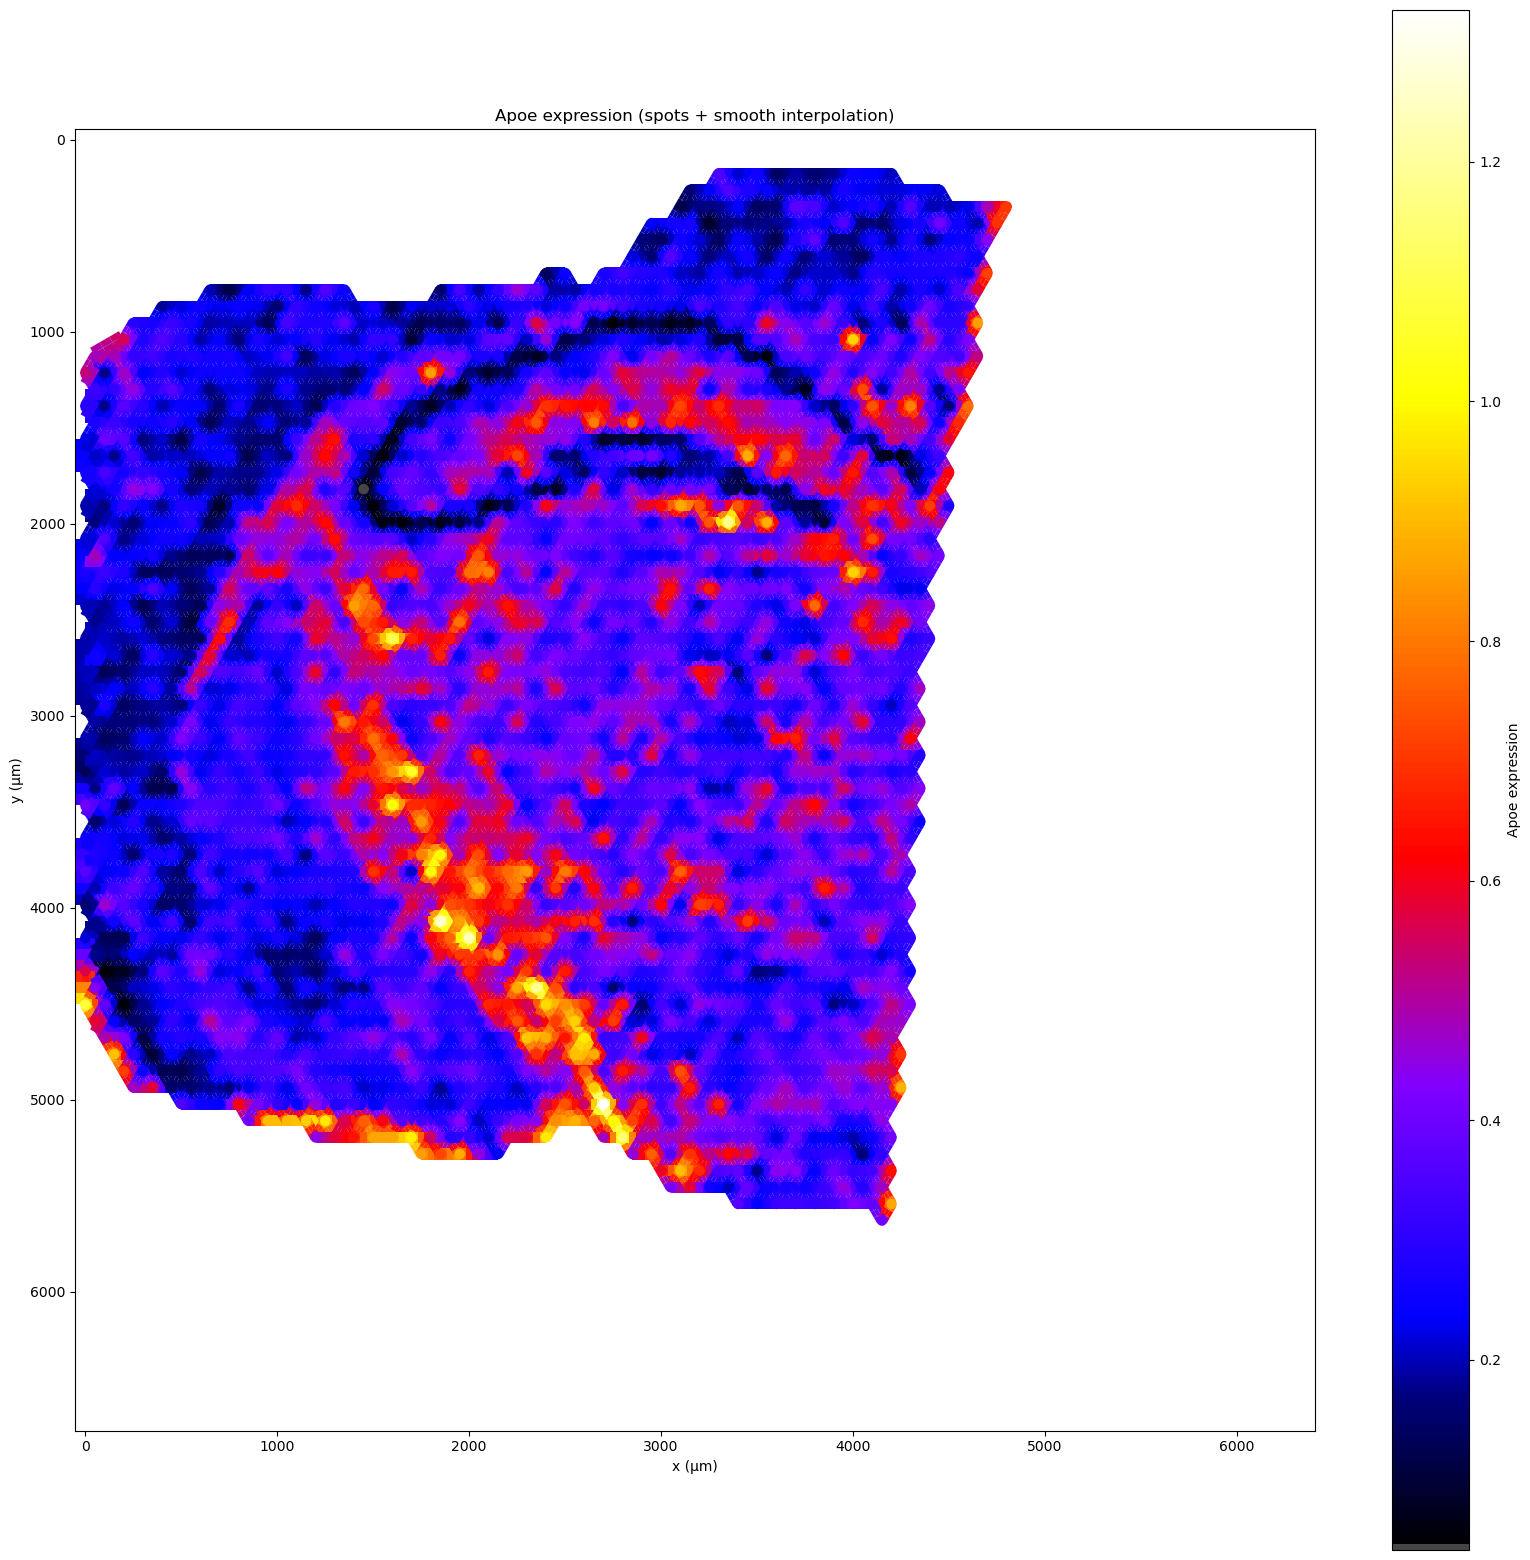

In [11]:
plot_spot_interpolation(
    rna_aad_4,
    tissue_positions,
    gene="Apoe",
    spot_diameter=55,
    spot_spacing=100,
    cmap_name=custom_cmap,
    figsize=(20, 20),
    alpha_rhombi=1,
    draw_poly_edges=False,
    draw_spot_edges=False
)

In [14]:
lipid_image_output_dir = "/home/ajarrah/PhD_Thesis/chapter_4/images/lipids/"
gene_image_output_dir = "/home/ajarrah/PhD_Thesis/chapter_4/images/genes/"

In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.patches import Circle, Polygon
from scipy.spatial import cKDTree


def rna_plot_producer_interpolater(
    adata,
    tissue_positions,
    gene,
    rna_sample_name="YC_1",
    output_dir="plots",
    spot_diameter=55,
    spot_spacing=100,
    cmap_name="viridis",
    figsize=(12, 12),
    alpha_rhombi=0.7,
    draw_poly_edges=False,
    draw_spot_edges=True,
):
    """
    Plot spatial transcriptomics spots with interpolated rhombus regions
    and save the figure as an image.

    Parameters
    ----------
    adata : AnnData
        Expression data (must include `var_names` for genes).
    tissue_positions : pd.DataFrame
        DataFrame with columns ['barcode', 'x_um', 'y_um'].
    gene : str
        Gene to visualize.
    rna_sample_name : str
        Name of the RNA sample for naming the file.
    output_dir : str
        Base directory to save images.
    Other parameters same as before.
    """

    # --- Step 1: extract data ---
    spot_radius = spot_diameter / 2
    x = tissue_positions["x_um"].values
    y = tissue_positions["y_um"].values

    expr = adata[:, adata.var_names == gene].X.toarray().flatten()
    barcode_to_expr = dict(zip(adata.obs_names, expr))
    expr_full = tissue_positions["barcode"].map(barcode_to_expr).to_numpy()

    vmin, vmax = np.nanmin(expr_full), np.nanmax(expr_full)

    # --- Step 2: build KDTree ---
    coords = np.column_stack([x, y])
    tree = cKDTree(coords)

    # --- Step 3: compute rhombi ---
    mid_polys, mid_vals = [], []
    for i, (xi, yi, vi) in enumerate(zip(x, y, expr_full)):
        if np.isnan(vi):
            continue
        dists, idxs = tree.query([xi, yi], k=7)  # self + 6 neighbors
        for j in idxs[1:]:
            if np.isnan(expr_full[j]):
                continue
            xj, yj, vj = x[j], y[j], expr_full[j]

            # Midpoint and averaged value
            mx, my = (xi + xj) / 2, (yi + yj) / 2
            mv = (vi + vj) / 2

            dx, dy = xj - xi, yj - yi
            length = np.sqrt(dx**2 + dy**2)
            if length == 0:
                continue

            px, py = -dy / length, dx / length
            half_short = length / (2 * np.sqrt(3))

            p1 = (mx - dx / 2, my - dy / 2)
            p2 = (mx + dx / 2, my + dy / 2)
            p3 = (mx + px * half_short, my + py * half_short)
            p4 = (mx - px * half_short, my - py * half_short)

            mid_polys.append([p1, p3, p2, p4])
            mid_vals.append(mv)

    # --- Step 4: plot ---
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_aspect("equal")

    cmap = plt.get_cmap(cmap_name) if isinstance(cmap_name, str) else cmap_name
    norm = Normalize(vmin=vmin, vmax=vmax)

    # rhombi
    for poly, val in zip(mid_polys, mid_vals):
        patch = Polygon(
            poly,
            closed=True,
            facecolor=cmap(norm(val)),
            edgecolor="k" if draw_poly_edges else "none",
            lw=0.2,
            alpha=alpha_rhombi,
        )
        ax.add_patch(patch)

    # circles
    for xi, yi, val in zip(x, y, expr_full):
        if not np.isnan(val):
            circle = Circle(
                (xi, yi),
                radius=spot_radius,
                facecolor=cmap(norm(val)),
                edgecolor="k" if draw_spot_edges else "none",
                lw=0.2,
            )
            ax.add_patch(circle)

    ax.set_xlim(x.min() - 2 * spot_radius, x.max() + 2 * spot_radius)
    ax.set_ylim(y.min() - 2 * spot_radius, y.max() + 2 * spot_radius)
    ax.invert_yaxis()
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.set_title(f"{gene} expression (spots + interpolated rhombi)")

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label=f"{gene} expression")

    # --- Step 5: save figure ---
    save_path = output_dir
    os.makedirs(save_path, exist_ok=True)
    filename = f'{gene}|{rna_sample_name}|{vmin:.2f}|{vmax:.2f}.png'
    fig.savefig(os.path.join(save_path, filename), dpi=300, bbox_inches='tight')
    plt.close(fig)

    print(f"Saved image to {os.path.join(save_path, filename)}")


In [21]:
rna_plot_producer_interpolater(
    adata = rna_data_name[0],
    tissue_positions=tissue_positions,
    gene="Apoe",
    rna_sample_name=rna_sample_name[0],
    output_dir=gene_image_output_dir,
    spot_diameter=55,
    spot_spacing=100,
    cmap_name=custom_cmap,
    figsize=(20, 20),
    alpha_rhombi=1,
    draw_poly_edges=False,
    draw_spot_edges=False
)

Saved image to /home/ajarrah/PhD_Thesis/chapter_4/images/genes/Apoe|YC_1|0.00|1.05.png


In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.patches import Circle, Polygon
from scipy.spatial import cKDTree


def rna_plot_producer_interpolater(
    adata,
    tissue_positions,
    gene,
    rna_sample_name="YC_1",
    output_dir="plots",
    spot_diameter=55,
    spot_spacing=100,
    cmap_name="viridis",
    figsize=(12, 12),
    alpha_rhombi=0.7,
    draw_poly_edges=False,
    draw_spot_edges=True,
    show_colorbar=True,
    show_axis=True,
    show_title=True,
):
    """
    Plot spatial transcriptomics spots with interpolated rhombus regions
    and save the figure as an image.

    Parameters
    ----------
    adata : AnnData
        Expression data (must include `var_names` for genes).
    tissue_positions : pd.DataFrame
        DataFrame with columns ['barcode', 'x_um', 'y_um'].
    gene : str
        Gene to visualize.
    rna_sample_name : str
        Name of the RNA sample for naming the file.
    output_dir : str
        Base directory to save images.
    show_colorbar : bool
        Whether to include the colorbar.
    show_axis : bool
        Whether to show axis lines, labels, and ticks.
    show_title : bool
        Whether to display a title.
    """

    # --- Step 1: extract data ---
    spot_radius = spot_diameter / 2
    x = tissue_positions["x_um"].values
    y = tissue_positions["y_um"].values

    expr = adata[:, adata.var_names == gene].X.toarray().flatten()
    barcode_to_expr = dict(zip(adata.obs_names, expr))
    expr_full = tissue_positions["barcode"].map(barcode_to_expr).to_numpy()

    vmin, vmax = np.nanmin(expr_full), np.nanmax(expr_full)

    # --- Step 2: build KDTree ---
    coords = np.column_stack([x, y])
    tree = cKDTree(coords)

    # --- Step 3: compute rhombi ---
    mid_polys, mid_vals = [], []
    for i, (xi, yi, vi) in enumerate(zip(x, y, expr_full)):
        if np.isnan(vi):
            continue
        dists, idxs = tree.query([xi, yi], k=7)  # self + 6 neighbors
        for j in idxs[1:]:
            if np.isnan(expr_full[j]):
                continue
            xj, yj, vj = x[j], y[j], expr_full[j]

            # Midpoint and averaged value
            mx, my = (xi + xj) / 2, (yi + yj) / 2
            mv = (vi + vj) / 2

            dx, dy = xj - xi, yj - yi
            length = np.sqrt(dx**2 + dy**2)
            if length == 0:
                continue

            px, py = -dy / length, dx / length
            half_short = length / (2 * np.sqrt(3))

            p1 = (mx - dx / 2, my - dy / 2)
            p2 = (mx + dx / 2, my + dy / 2)
            p3 = (mx + px * half_short, my + py * half_short)
            p4 = (mx - px * half_short, my - py * half_short)

            mid_polys.append([p1, p3, p2, p4])
            mid_vals.append(mv)

    # --- Step 4: plot ---
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_aspect("equal")

    cmap = plt.get_cmap(cmap_name) if isinstance(cmap_name, str) else cmap_name
    norm = Normalize(vmin=vmin, vmax=vmax)

    # rhombi
    for poly, val in zip(mid_polys, mid_vals):
        patch = Polygon(
            poly,
            closed=True,
            facecolor=cmap(norm(val)),
            edgecolor="k" if draw_poly_edges else "none",
            lw=0.2,
            alpha=alpha_rhombi,
        )
        ax.add_patch(patch)

    # circles
    for xi, yi, val in zip(x, y, expr_full):
        if not np.isnan(val):
            circle = Circle(
                (xi, yi),
                radius=spot_radius,
                facecolor=cmap(norm(val)),
                edgecolor="k" if draw_spot_edges else "none",
                lw=0.2,
            )
            ax.add_patch(circle)

    ax.set_xlim(x.min() - 2 * spot_radius, x.max() + 2 * spot_radius)
    ax.set_ylim(y.min() - 2 * spot_radius, y.max() + 2 * spot_radius)
    ax.invert_yaxis()

    # Optional components
    if show_axis:
        ax.set_xlabel("x (µm)")
        ax.set_ylabel("y (µm)")
    else:
        ax.axis("off")

    if show_title:
        ax.set_title(f"{gene} expression (spots + interpolated rhombi)")

    if show_colorbar:
        sm = ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        fig.colorbar(sm, ax=ax, label=f"{gene} expression")

    # --- Step 5: save figure ---
    os.makedirs(output_dir, exist_ok=True)
    filename = f'{gene}|{rna_sample_name}|{vmin:.2f}|{vmax:.2f}.png'
    fig.savefig(os.path.join(output_dir, filename), dpi=300, bbox_inches='tight')
    plt.close(fig)

    print(f"Saved image to {os.path.join(output_dir, filename)}")


In [24]:
rna_plot_producer_interpolater(
    adata = rna_data_name[0],
    tissue_positions=tissue_positions,
    gene="Apoe",
    rna_sample_name=rna_sample_name[0],
    output_dir=gene_image_output_dir,
    spot_diameter=55,
    spot_spacing=100,
    cmap_name=custom_cmap,
    figsize=(20, 20),
    alpha_rhombi=1,
    draw_poly_edges=False,
    draw_spot_edges=False,
    show_colorbar=False,
    show_axis=False,
    show_title=False
)

Saved image to /home/ajarrah/PhD_Thesis/chapter_4/images/genes/Apoe|YC_1|0.00|1.05.png
